# K-Means Clustering Visualization with t-SNE

This notebook visualizes the k-means clustering results for HAM10000 embeddings using t-SNE dimensionality reduction.

We'll plot clusters for k=[1, 3, 5, 10] to show how images are grouped.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap.umap_ as umap

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

/home/nqmtien/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-22 08:39:16.164331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load HAM10000 Data

In [2]:
# Paths
embeddings_path = Path('../dnn/embeddings/ham10000/train.pkl')
groundtruth_path = Path('../../datasets/ham10000/groundtruth/train.csv')

# Load embeddings
print("Loading embeddings...")
with open(embeddings_path, 'rb') as f:
    embeddings = pickle.load(f)
embeddings = np.array(embeddings)

print(f"Embeddings shape: {embeddings.shape}")

# Load groundtruth for class labels
df = pd.read_csv(groundtruth_path)
class_labels = df['dx'].values

print(f"Number of samples: {len(embeddings)}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"\nClass distribution:")
print(df['dx'].value_counts())

Loading embeddings...
Embeddings shape: (5198, 1280)
Number of samples: 5198
Embedding dimension: 1280

Class distribution:
dx
nv     3364
mel    1834
Name: count, dtype: int64


## Apply t-SNE Dimensionality Reduction

First, we reduce the high-dimensional embeddings to 2D using t-SNE for visualization.

In [3]:
print("Applying t-SNE dimensionality reduction...")
print("This may take a few minutes...")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    verbose=1
)

embeddings_2d = tsne.fit_transform(embeddings)

print(f"\nt-SNE reduced shape: {embeddings_2d.shape}")

Applying t-SNE dimensionality reduction...
This may take a few minutes...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5198 samples in 0.002s...


/home/nqmtien/.local/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5198 samples in 0.510s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5198
[t-SNE] Computed conditional probabilities for sample 2000 / 5198
[t-SNE] Computed conditional probabilities for sample 3000 / 5198
[t-SNE] Computed conditional probabilities for sample 4000 / 5198
[t-SNE] Computed conditional probabilities for sample 5000 / 5198
[t-SNE] Computed conditional probabilities for sample 5198 / 5198
[t-SNE] Mean sigma: 0.020427
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.629581
[t-SNE] KL divergence after 1000 iterations: 0.619764

t-SNE reduced shape: (5198, 2)


In [4]:
print("Applying UMAP dimensionality reduction...")
print("This may take a few minutes...")

umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    verbose=True,
    random_state=42
)

embeddings_2d_umap = umap_reducer.fit_transform(embeddings)

print(f"\nUMAP reduced shape: {embeddings_2d_umap.shape}")

Applying UMAP dimensionality reduction...
This may take a few minutes...


SyntaxError: keyword argument repeated: random_state (566575896.py, line 11)

## Apply UMAP Dimensionality Reduction

We'll also apply UMAP, which often preserves both local and global structure better than t-SNE.

## Visualize Ground Truth Classes

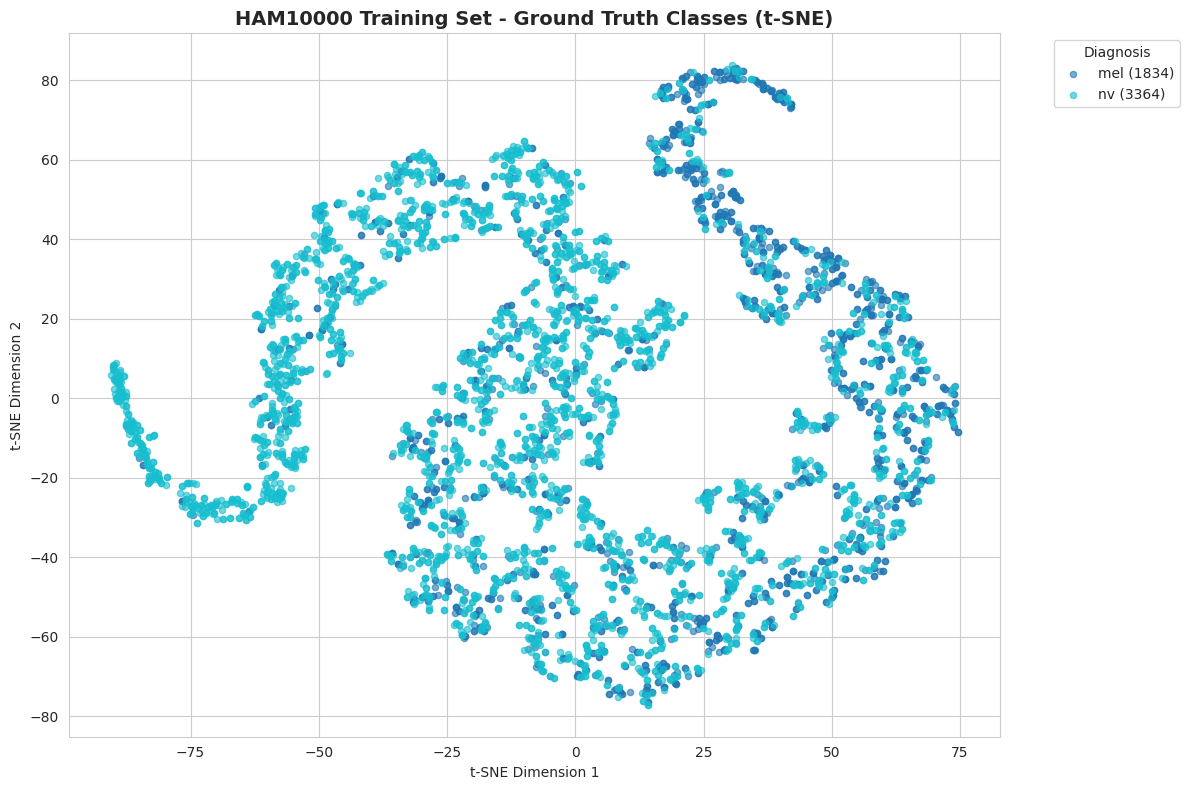

Ground truth visualization complete!


In [ ]:
# Plot ground truth classes
fig, ax = plt.subplots(figsize=(12, 8))

# Create color map for classes
unique_classes = np.unique(class_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
class_to_color = {cls: colors[i] for i, cls in enumerate(unique_classes)}

for cls in unique_classes:
    mask = class_labels == cls
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[class_to_color[cls]],
        label=f'{cls} ({mask.sum()})',
        alpha=0.6,
        s=20
    )

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('HAM10000 Training Set - Ground Truth Classes (t-SNE)', fontsize=14, fontweight='bold')
ax.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Ground truth visualization complete!")

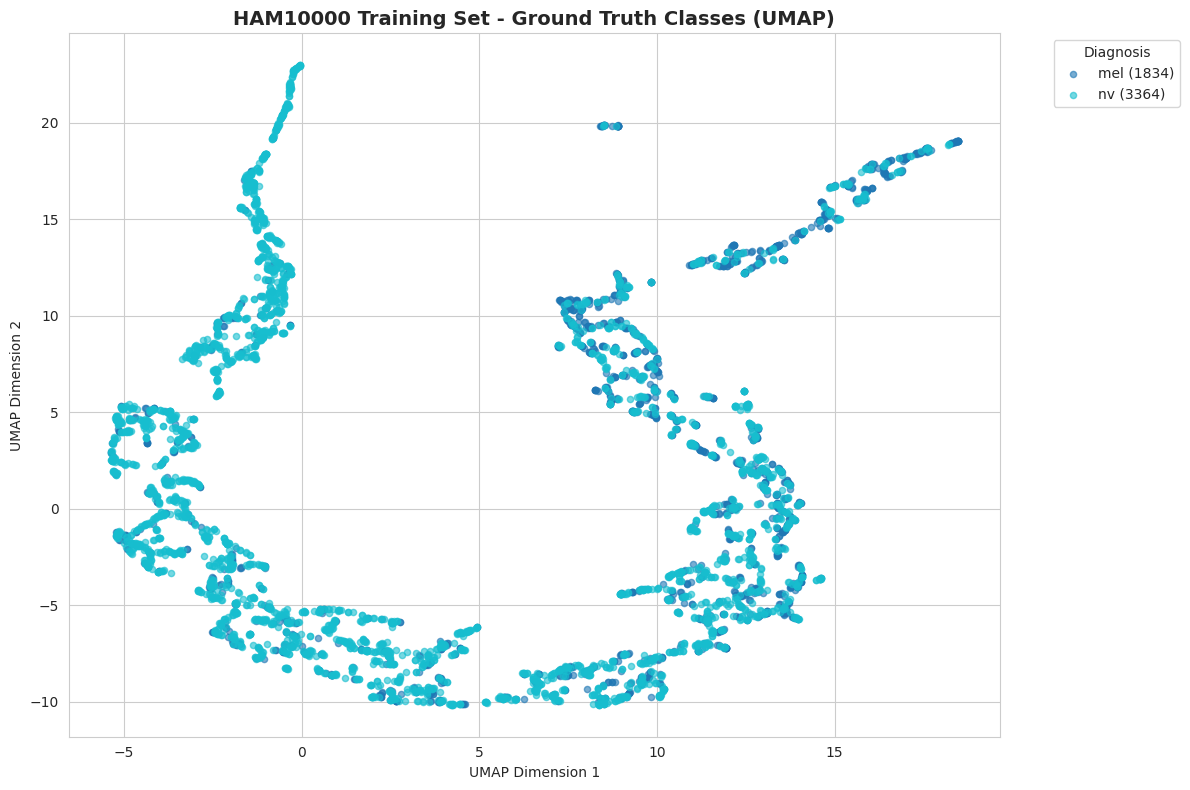

Ground truth UMAP visualization complete!


In [ ]:
# Plot ground truth classes with UMAP
fig, ax = plt.subplots(figsize=(12, 8))

# Use same color map for consistency
for cls in unique_classes:
    mask = class_labels == cls
    ax.scatter(
        embeddings_2d_umap[mask, 0],
        embeddings_2d_umap[mask, 1],
        c=[class_to_color[cls]],
        label=f'{cls} ({mask.sum()})',
        alpha=0.6,
        s=20
    )

ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title('HAM10000 Training Set - Ground Truth Classes (UMAP)', fontsize=14, fontweight='bold')
ax.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Ground truth UMAP visualization complete!")

## Visualize Ground Truth Classes with UMAP

## K-Means Clustering for Different k Values

In [ ]:
# K values to test
k_values = [1, 2, 3, 5, 8, 10]

# Apply k-means for each k
cluster_results = {}

for k in k_values:
    print(f"\nApplying k-means with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    cluster_results[k] = {
        'labels': cluster_labels,
        'centroids': kmeans.cluster_centers_,
        'inertia': kmeans.inertia_
    }
    
    print(f"  Inertia: {kmeans.inertia_:.2f}")
    
    # Show cluster distribution
    unique, counts = np.unique(cluster_labels, return_counts=True)
    print(f"  Cluster distribution: {dict(zip(unique, counts))}")

print("\nK-means clustering complete!")


Applying k-means with k=1...
  Inertia: 2083.15
  Cluster distribution: {np.int32(0): np.int64(5198)}

Applying k-means with k=2...
  Inertia: 856.32
  Cluster distribution: {np.int32(0): np.int64(2901), np.int32(1): np.int64(2297)}

Applying k-means with k=3...
  Inertia: 427.06
  Cluster distribution: {np.int32(0): np.int64(1869), np.int32(1): np.int64(2554), np.int32(2): np.int64(775)}

Applying k-means with k=5...
  Inertia: 188.58
  Cluster distribution: {np.int32(0): np.int64(1064), np.int32(1): np.int64(1582), np.int32(2): np.int64(283), np.int32(3): np.int64(1457), np.int32(4): np.int64(812)}

Applying k-means with k=8...
  Inertia: 89.56
  Cluster distribution: {np.int32(0): np.int64(890), np.int32(1): np.int64(829), np.int32(2): np.int64(250), np.int32(3): np.int64(1154), np.int32(4): np.int64(513), np.int32(5): np.int64(506), np.int32(6): np.int64(1006), np.int32(7): np.int64(50)}

Applying k-means with k=10...
  Inertia: 63.65
  Cluster distribution: {np.int32(0): np.int64

## Visualize K-Means Clusters for All k Values

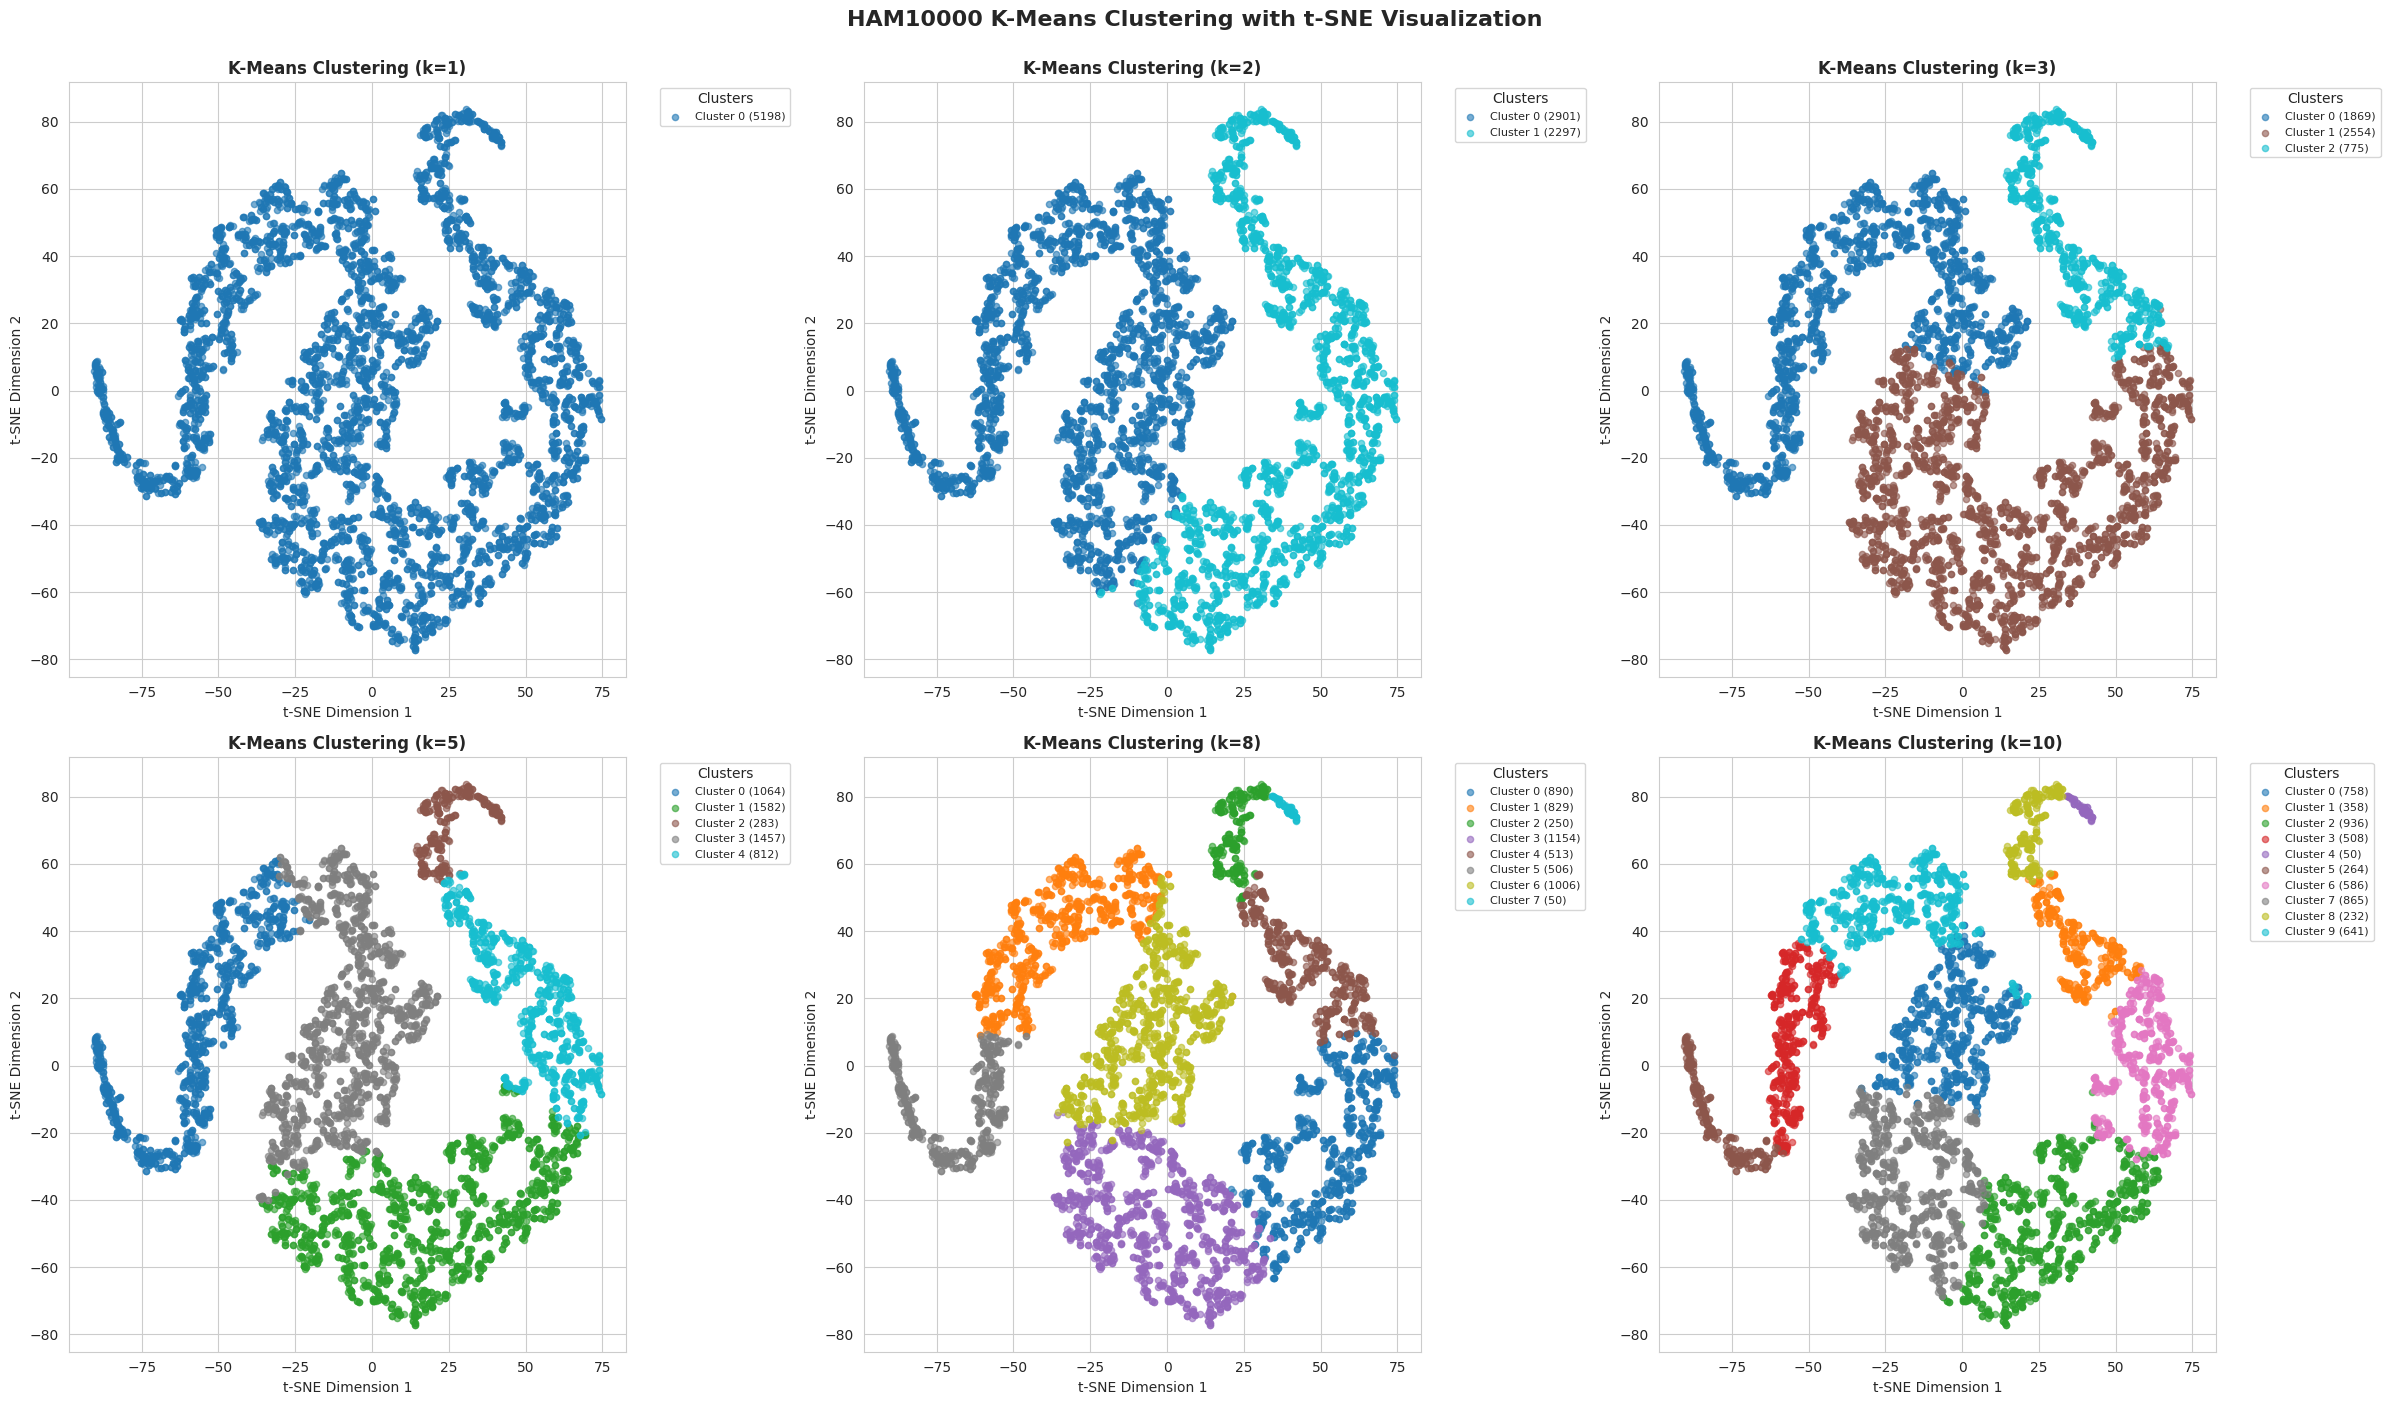

Cluster visualization complete!


In [ ]:
# Create 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    cluster_labels = cluster_results[k]['labels']
    
    # Create color map for clusters
    if k <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, k))
    else:
        colors = plt.cm.tab20(np.linspace(0, 1, k))
    
    # Plot each cluster
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id} ({mask.sum()})',
            alpha=0.6,
            s=20
        )
    
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_title(f'K-Means Clustering (k={k})', fontsize=12, fontweight='bold')
    ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('HAM10000 K-Means Clustering with t-SNE Visualization', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Cluster visualization complete!")

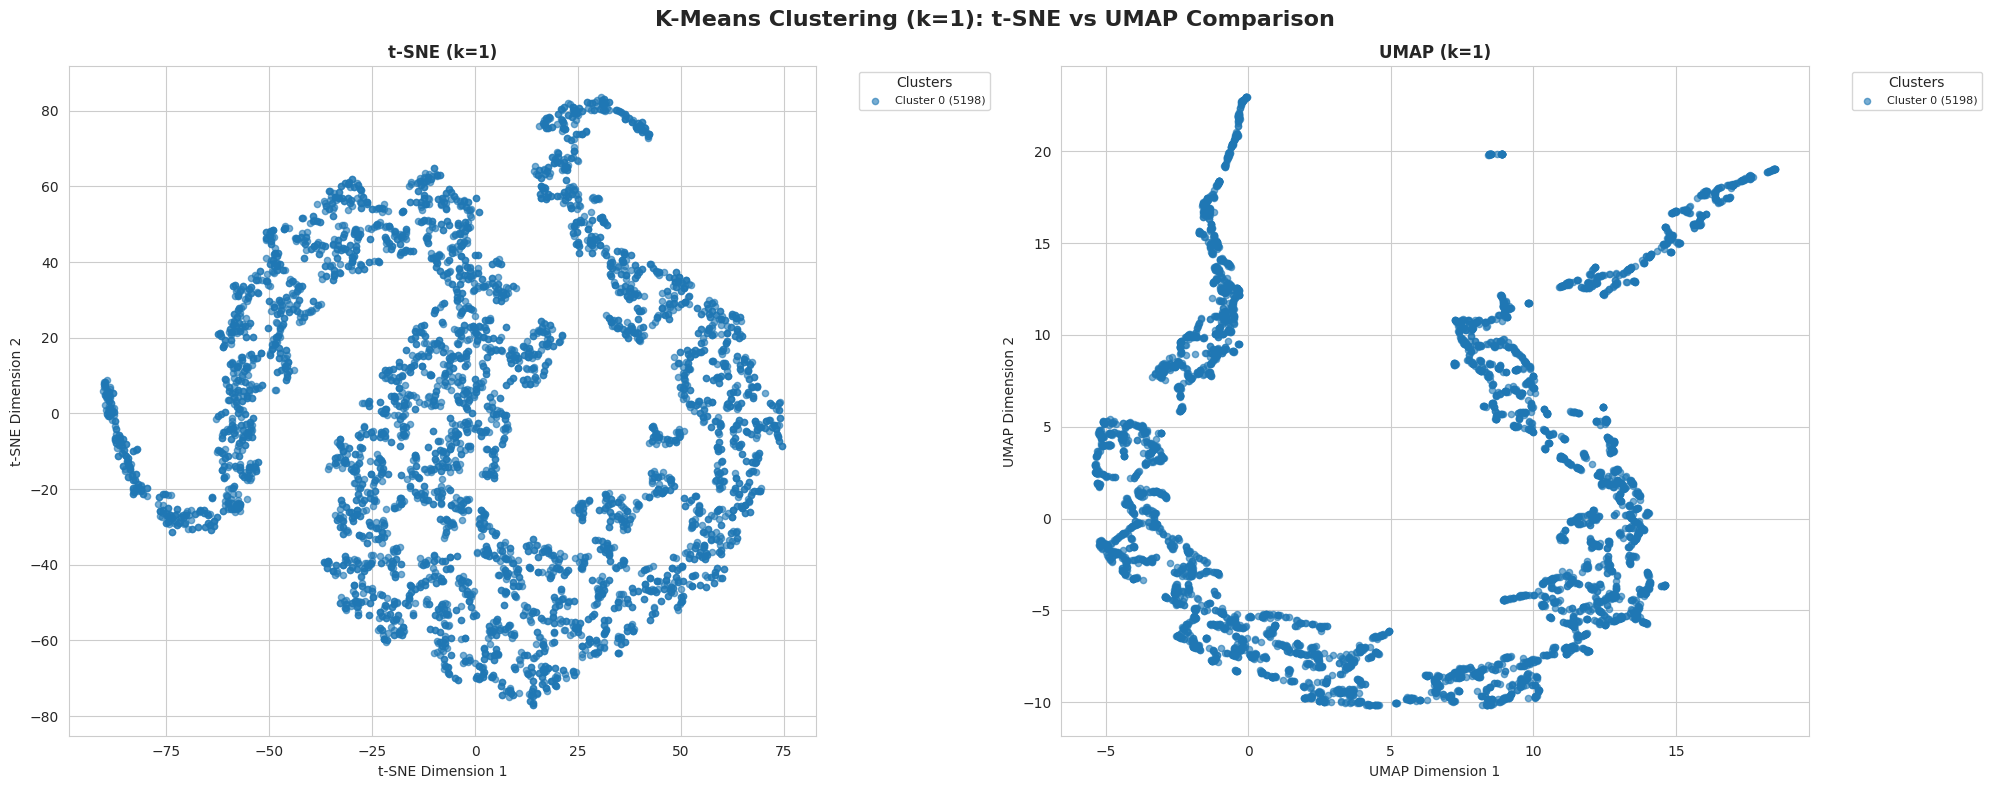

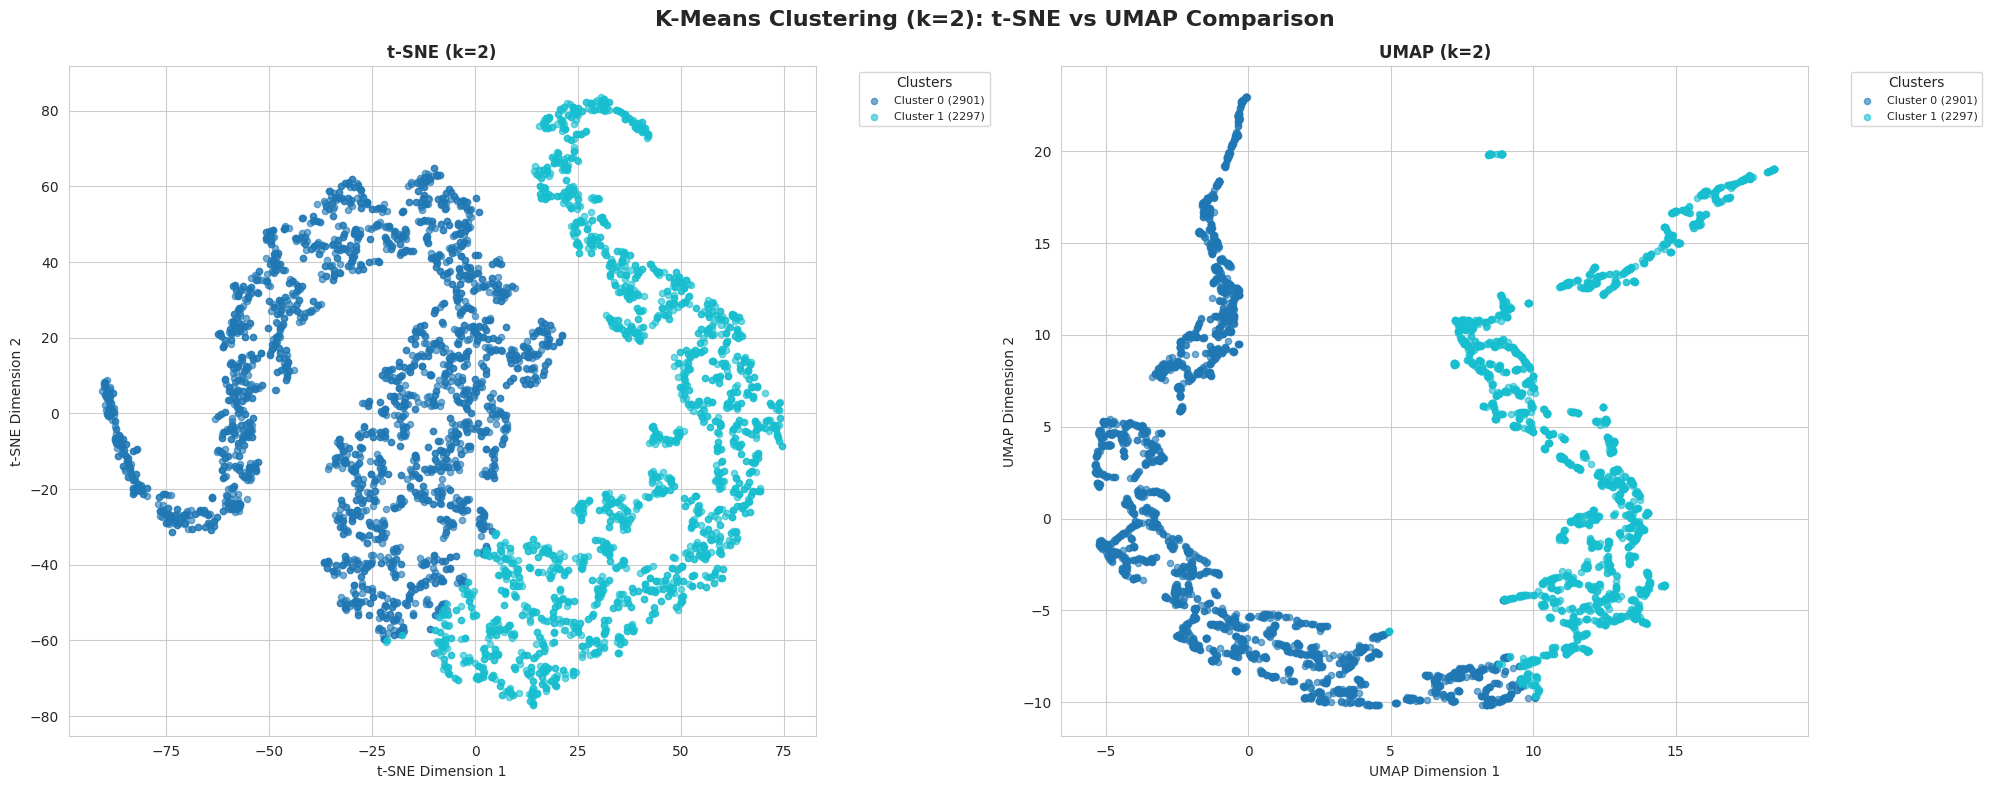

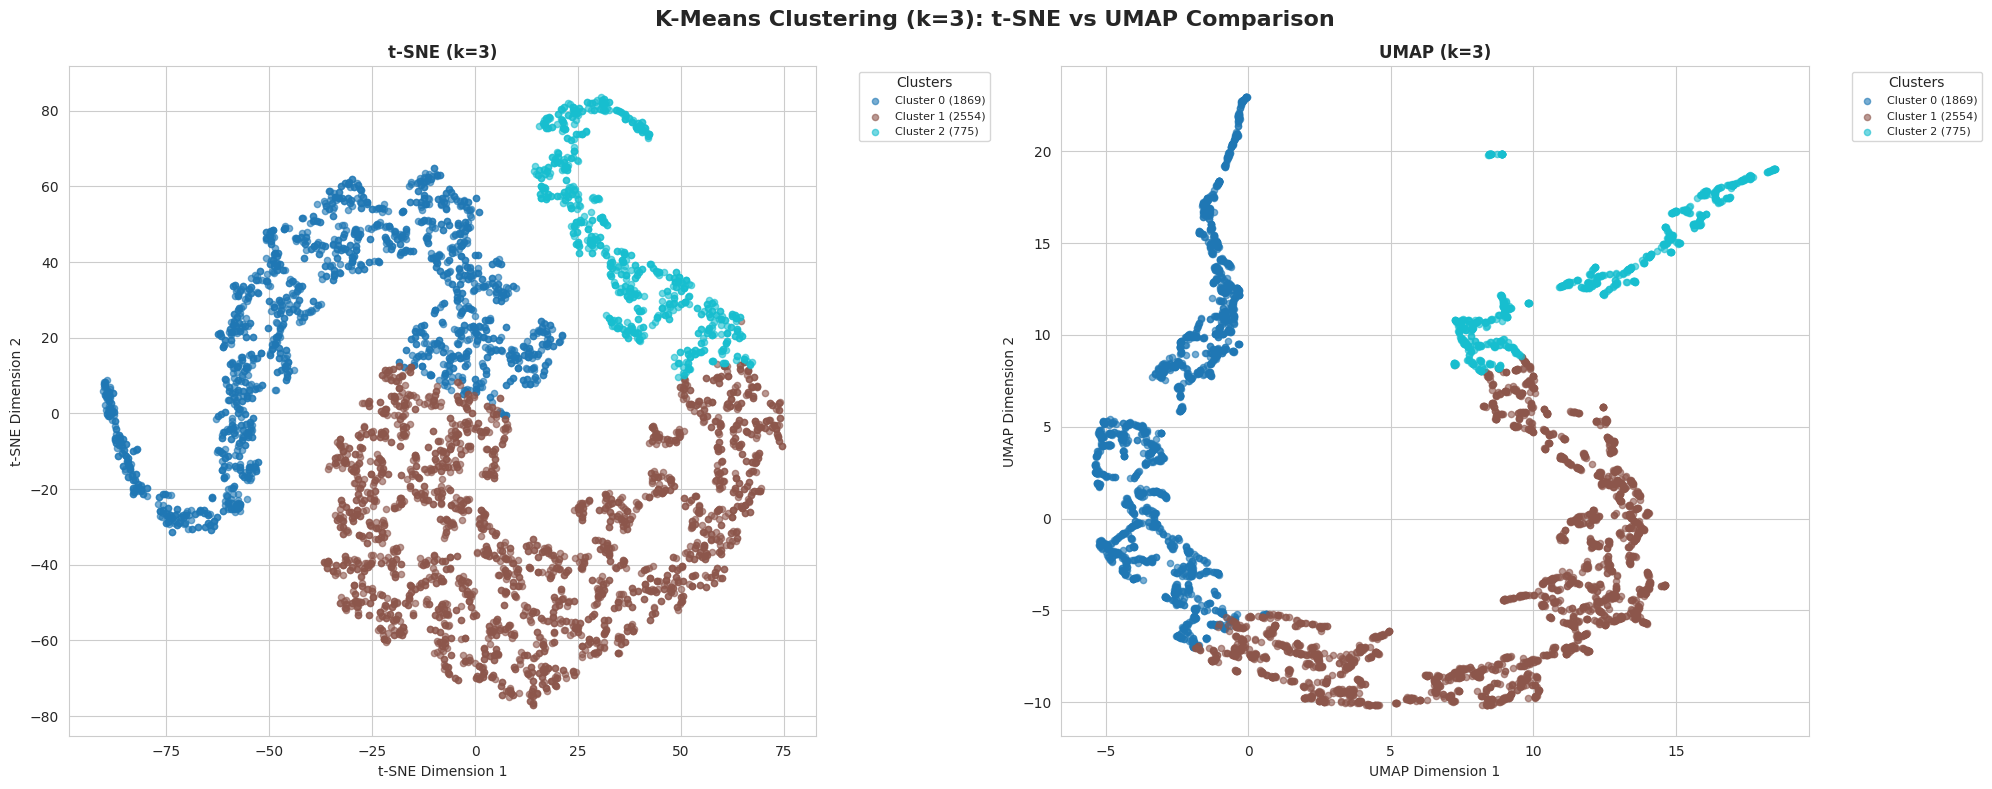

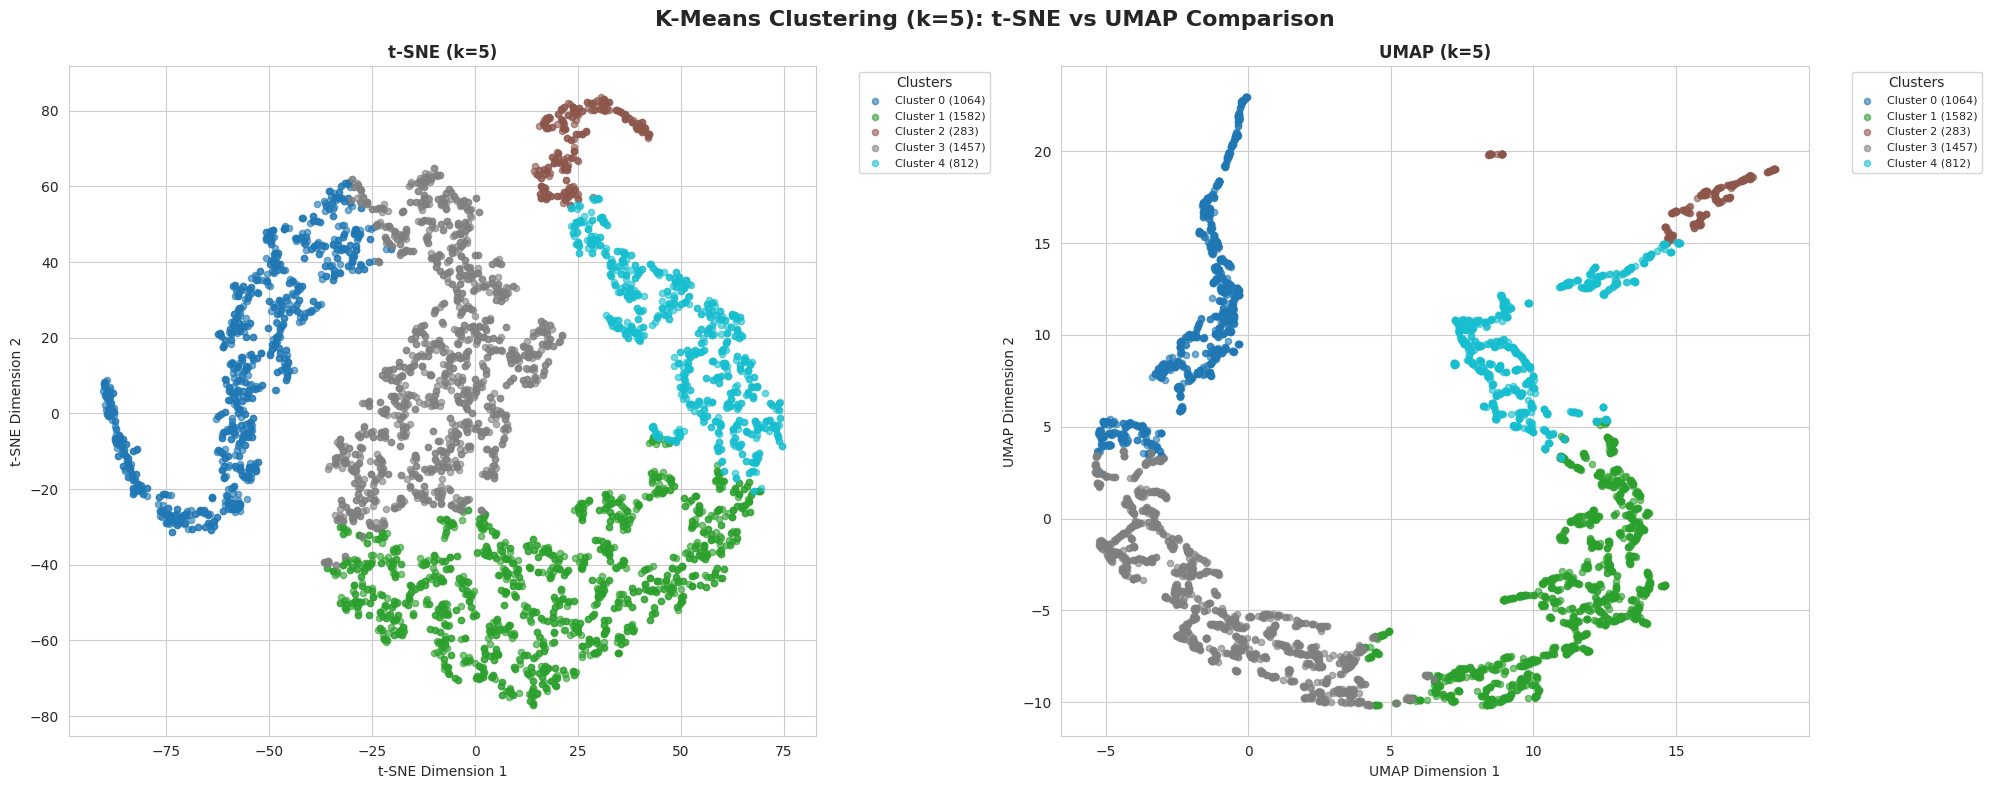

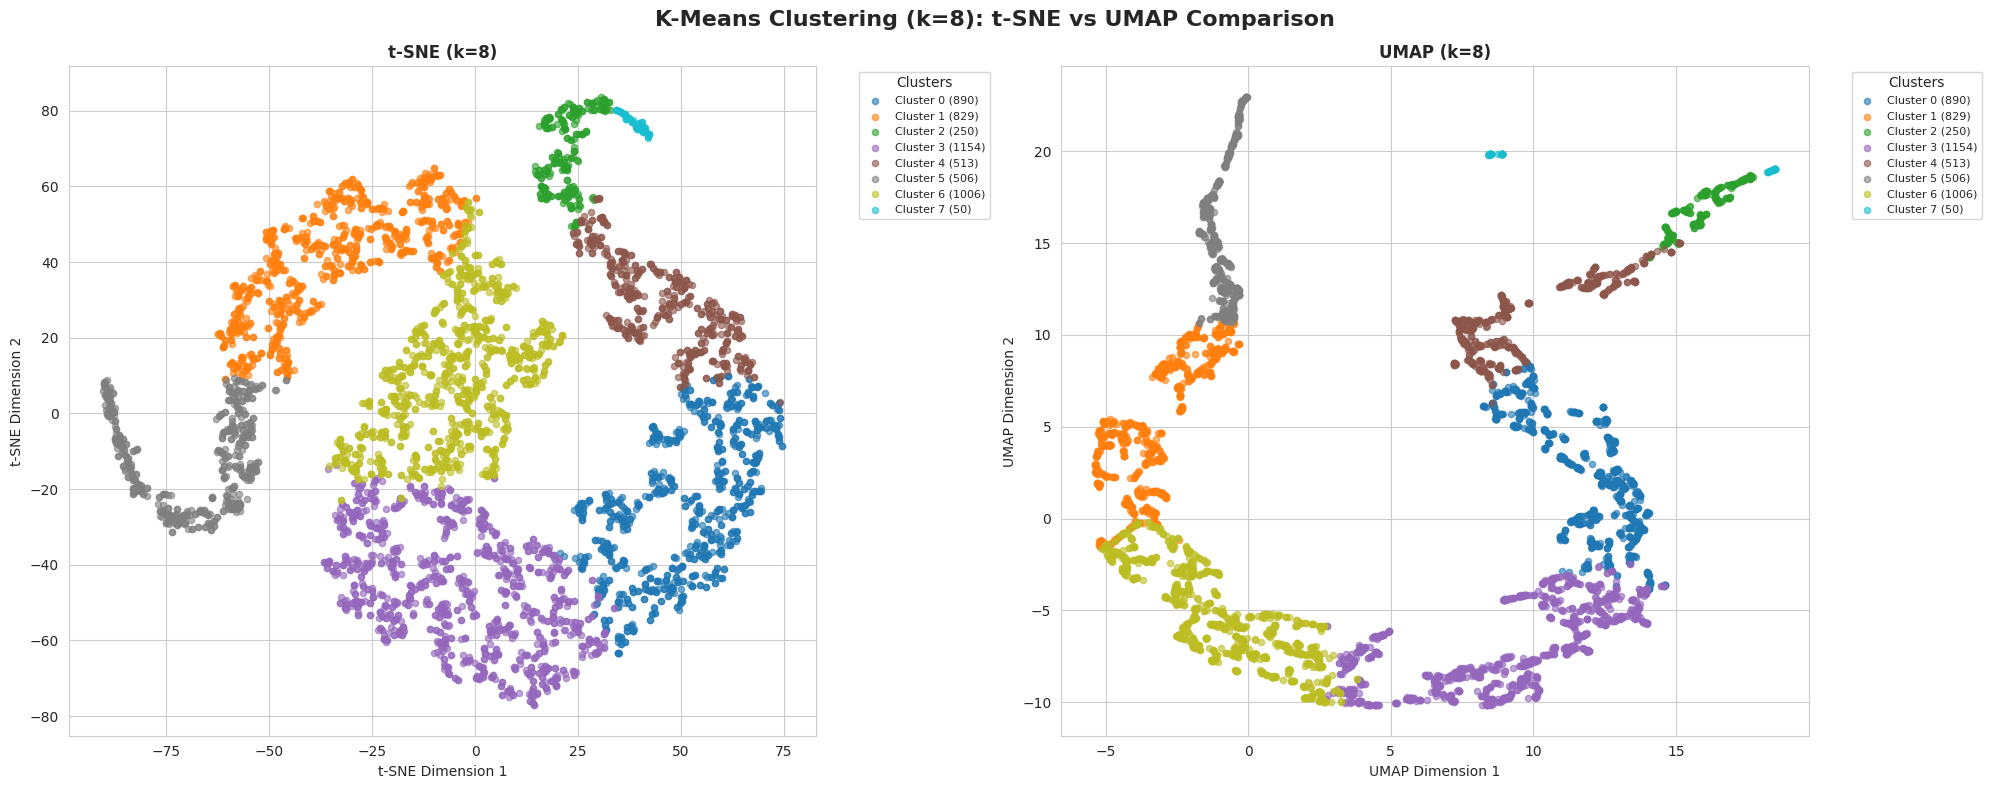

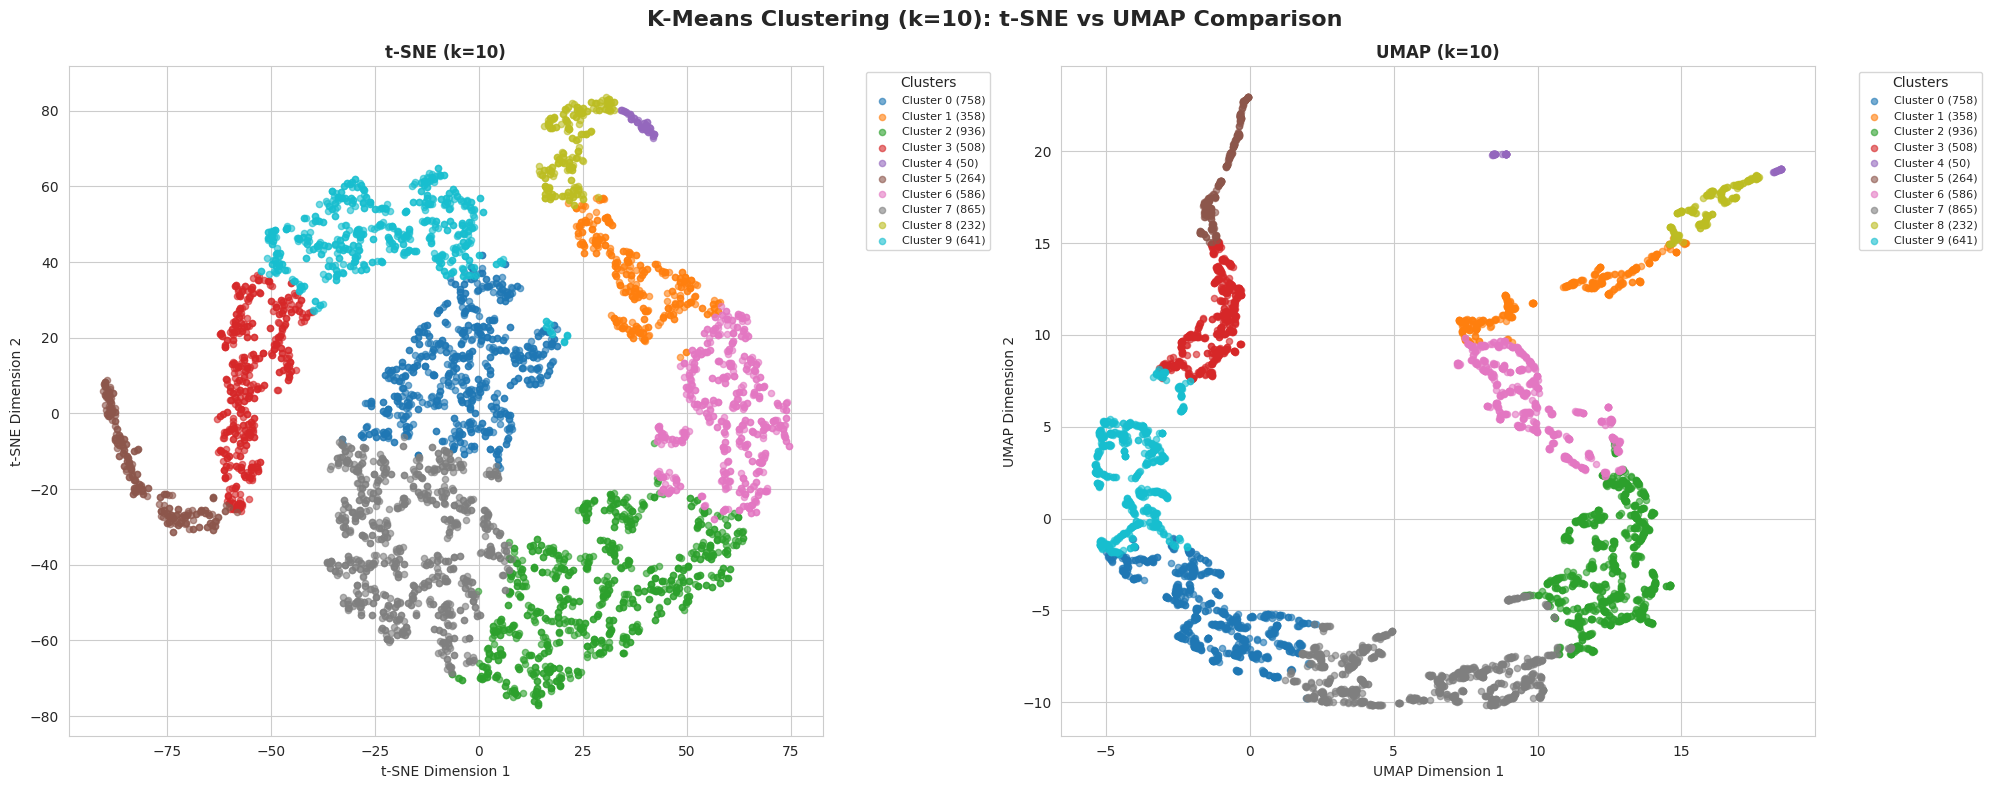

Comparison visualization complete!


In [ ]:
# Compare t-SNE and UMAP for each k value
for k in k_values:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    cluster_labels = cluster_results[k]['labels']
    
    # Create color map for clusters
    if k <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, k))
    else:
        colors = plt.cm.tab20(np.linspace(0, 1, k))
    
    # t-SNE plot
    ax = axes[0]
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id} ({mask.sum()})',
            alpha=0.6,
            s=20
        )
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_title(f't-SNE (k={k})', fontsize=12, fontweight='bold')
    ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # UMAP plot
    ax = axes[1]
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        ax.scatter(
            embeddings_2d_umap[mask, 0],
            embeddings_2d_umap[mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id} ({mask.sum()})',
            alpha=0.6,
            s=20
        )
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'UMAP (k={k})', fontsize=12, fontweight='bold')
    ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.suptitle(f'K-Means Clustering (k={k}): t-SNE vs UMAP Comparison', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Comparison visualization complete!")

## Compare t-SNE vs UMAP Side-by-Side

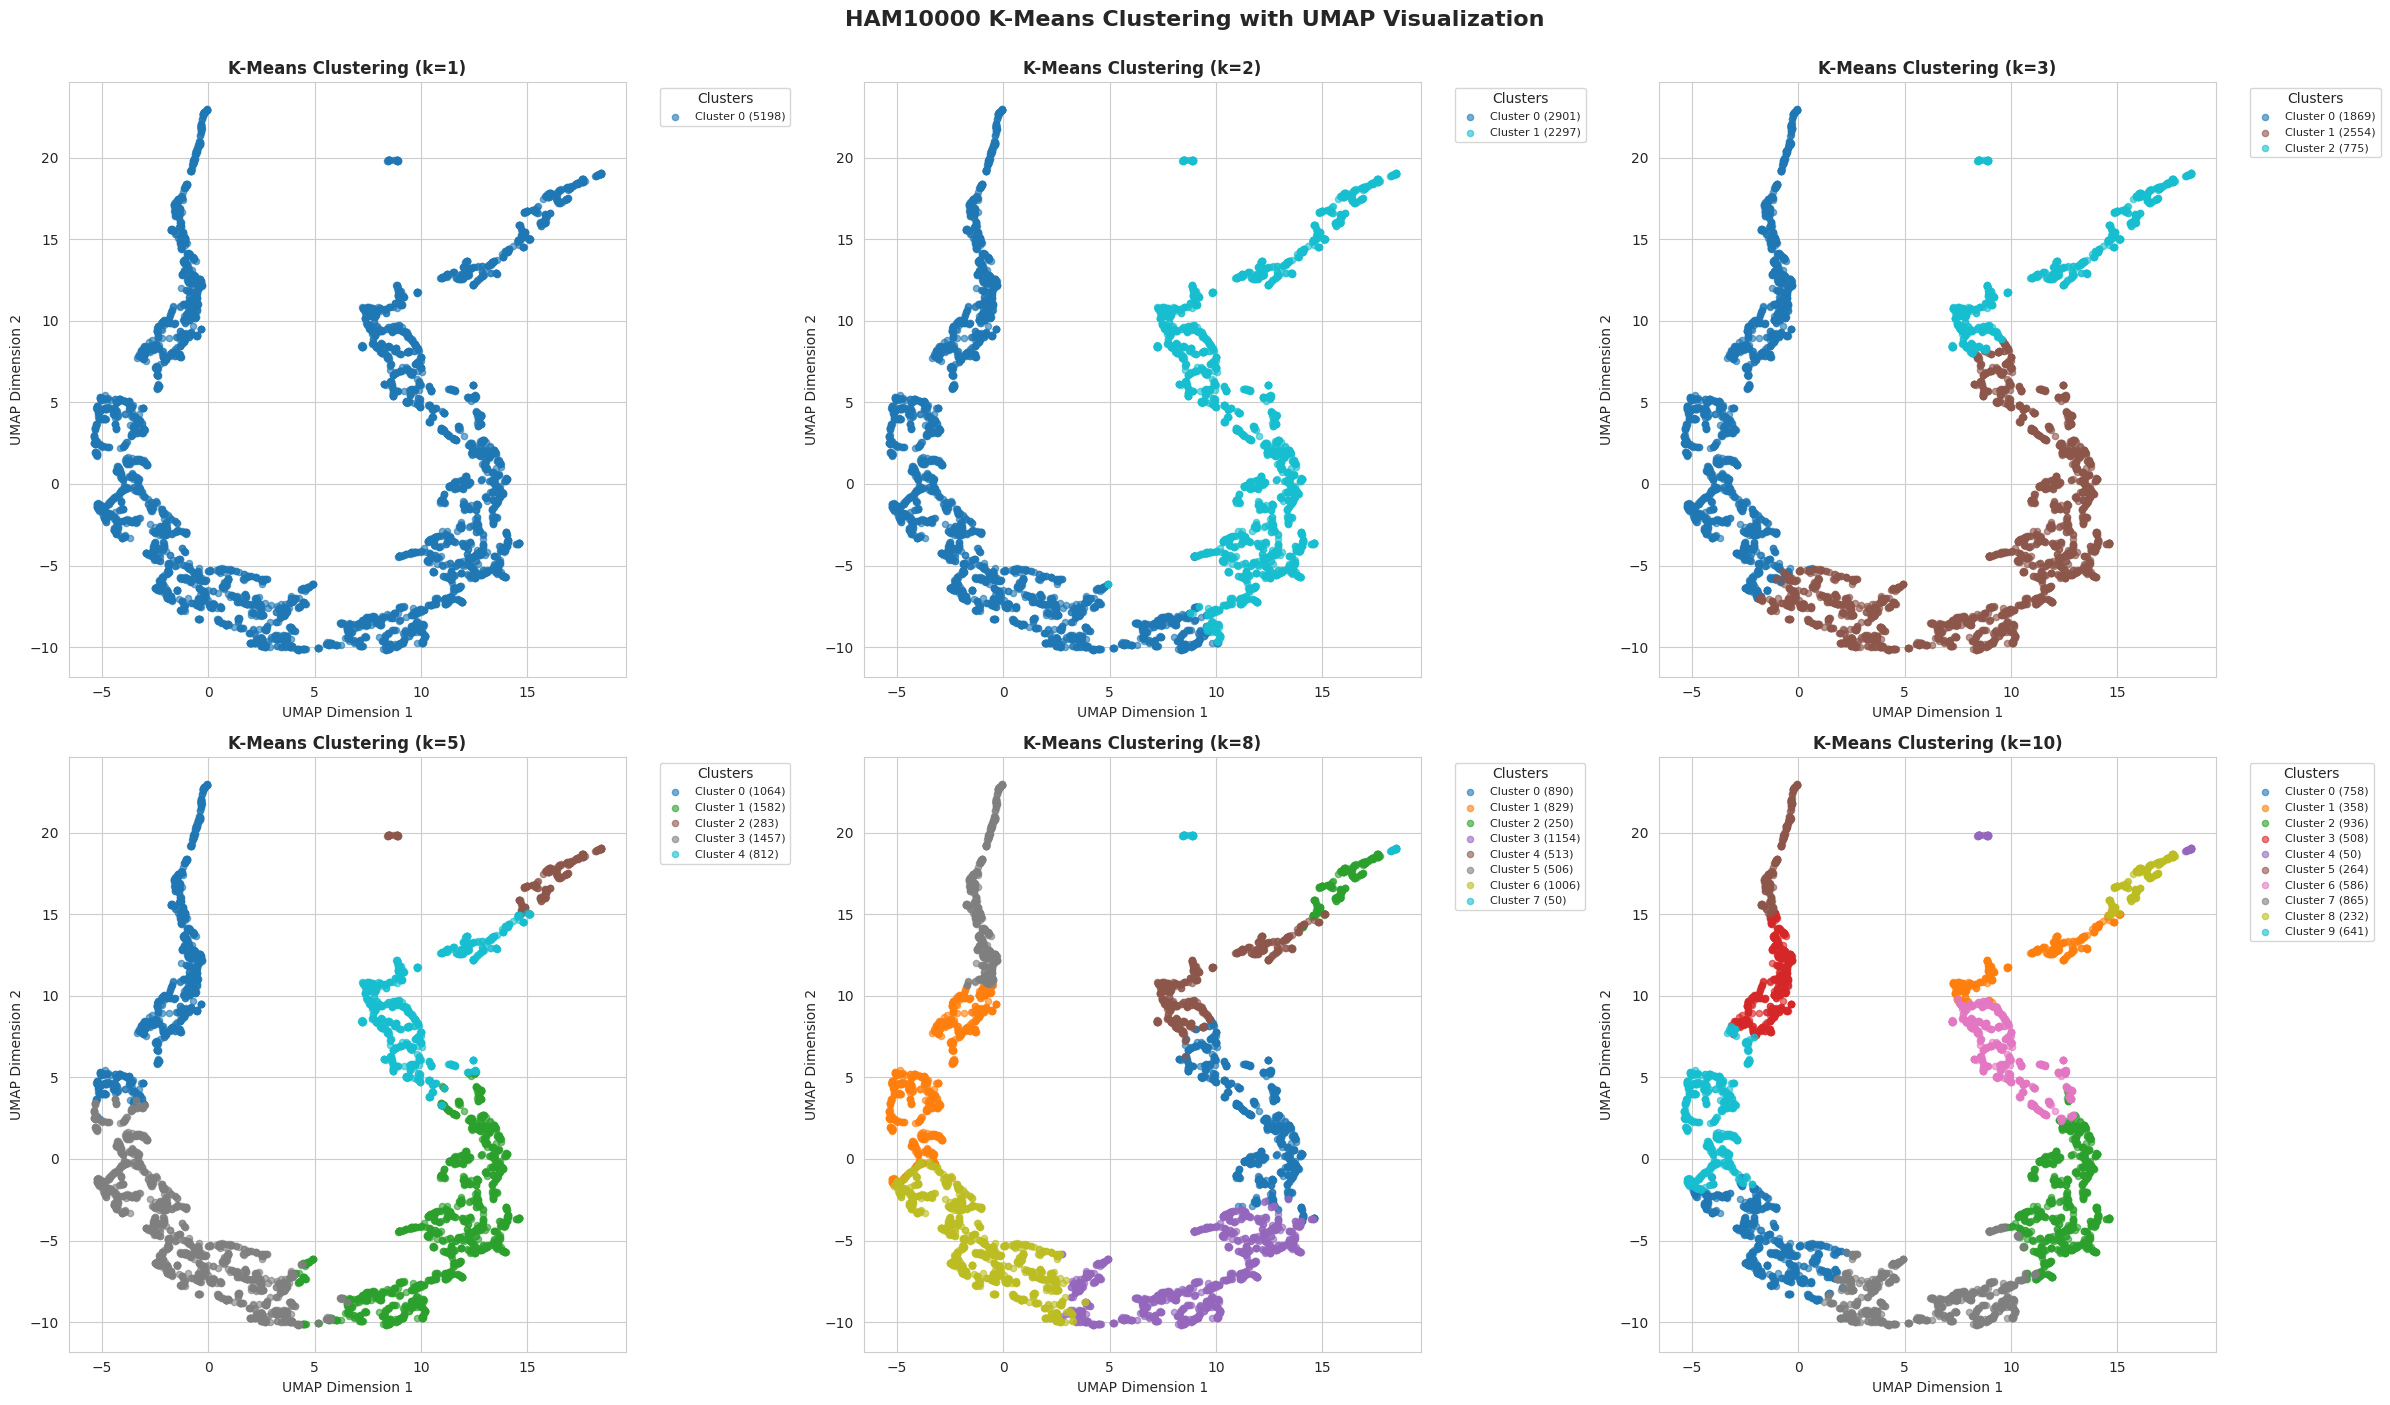

UMAP cluster visualization complete!


In [ ]:
# Create 2x3 subplot for UMAP
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    cluster_labels = cluster_results[k]['labels']
    
    # Create color map for clusters
    if k <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, k))
    else:
        colors = plt.cm.tab20(np.linspace(0, 1, k))
    
    # Plot each cluster
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        ax.scatter(
            embeddings_2d_umap[mask, 0],
            embeddings_2d_umap[mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id} ({mask.sum()})',
            alpha=0.6,
            s=20
        )
    
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'K-Means Clustering (k={k})', fontsize=12, fontweight='bold')
    ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('HAM10000 K-Means Clustering with UMAP Visualization', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("UMAP cluster visualization complete!")

## Visualize K-Means Clusters with UMAP

## Analyze Cluster Composition by Class

In [ ]:
# For each k, show which classes are in which clusters
for k in k_values:
    print(f"\n{'='*80}")
    print(f"Cluster Composition for k={k}")
    print(f"{'='*80}")
    
    cluster_labels = cluster_results[k]['labels']
    
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        cluster_classes = class_labels[mask]
        
        print(f"\nCluster {cluster_id} ({mask.sum()} images):")
        
        # Count classes in this cluster
        unique, counts = np.unique(cluster_classes, return_counts=True)
        class_dist = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)
        
        for cls, count in class_dist:
            percentage = (count / mask.sum()) * 100
            print(f"  {cls:10s}: {count:4d} images ({percentage:5.1f}%)")


Cluster Composition for k=1

Cluster 0 (5198 images):
  nv        : 3364 images ( 64.7%)
  mel       : 1834 images ( 35.3%)

Cluster Composition for k=2

Cluster 0 (2901 images):
  nv        : 2332 images ( 80.4%)
  mel       :  569 images ( 19.6%)

Cluster 1 (2297 images):
  mel       : 1265 images ( 55.1%)
  nv        : 1032 images ( 44.9%)

Cluster Composition for k=3

Cluster 0 (1869 images):
  nv        : 1596 images ( 85.4%)
  mel       :  273 images ( 14.6%)

Cluster 1 (2554 images):
  nv        : 1554 images ( 60.8%)
  mel       : 1000 images ( 39.2%)

Cluster 2 (775 images):
  mel       :  561 images ( 72.4%)
  nv        :  214 images ( 27.6%)

Cluster Composition for k=5

Cluster 0 (1064 images):
  nv        :  945 images ( 88.8%)
  mel       :  119 images ( 11.2%)

Cluster 1 (1582 images):
  nv        :  949 images ( 60.0%)
  mel       :  633 images ( 40.0%)

Cluster 2 (283 images):
  mel       :  218 images ( 77.0%)
  nv        :   65 images ( 23.0%)

Cluster 3 (1457 image

## Cluster Purity Analysis


Cluster Purity Analysis
k= 1: Average purity = 0.647
k= 2: Average purity = 0.677
k= 3: Average purity = 0.729
k= 5: Average purity = 0.736
k= 8: Average purity = 0.747
k=10: Average purity = 0.761


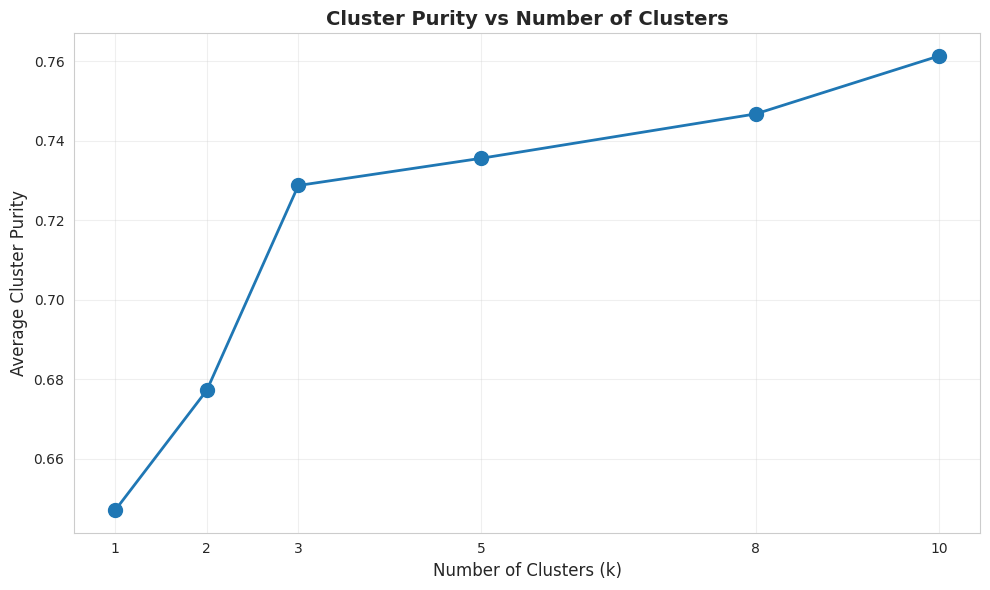

In [ ]:
# Calculate cluster purity for each k
print("\nCluster Purity Analysis")
print("="*50)

purity_results = []

for k in k_values:
    cluster_labels = cluster_results[k]['labels']
    
    # Calculate purity for each cluster
    purities = []
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        cluster_classes = class_labels[mask]
        
        # Purity = fraction of most common class
        unique, counts = np.unique(cluster_classes, return_counts=True)
        max_count = counts.max()
        purity = max_count / len(cluster_classes)
        purities.append(purity)
    
    avg_purity = np.mean(purities)
    purity_results.append((k, avg_purity))
    
    print(f"k={k:2d}: Average purity = {avg_purity:.3f}")

# Plot purity vs k
fig, ax = plt.subplots(figsize=(10, 6))
k_vals, purities = zip(*purity_results)
ax.plot(k_vals, purities, marker='o', linewidth=2, markersize=10)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Average Cluster Purity', fontsize=12)
ax.set_title('Cluster Purity vs Number of Clusters', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_vals)
plt.tight_layout()
plt.show()

## Compare with Generated Cluster Files

In [ ]:
# Load and compare with the actual cluster files generated by clustering.py
print("\nComparing with Generated Cluster Files")
print("="*80)

cluster_dir = Path('clusters/ham10000')

if cluster_dir.exists():
    for k in k_values:
        cluster_file = cluster_dir / f'{k}.json'
        
        if cluster_file.exists():
            with open(cluster_file, 'r') as f:
                saved_clusters = json.load(f)
            
            print(f"\nk={k}: Found saved cluster file with {len(saved_clusters)} clusters")
            
            # Show cluster sizes
            for cluster in saved_clusters[:3]:  # Show first 3
                cluster_id = cluster['cluster_id']
                num_images = len(cluster['images'])
                print(f"  Cluster {cluster_id}: {num_images} images")
            
            if len(saved_clusters) > 3:
                print(f"  ... and {len(saved_clusters) - 3} more clusters")
        else:
            print(f"\nk={k}: Cluster file not found at {cluster_file}")
else:
    print(f"Cluster directory not found: {cluster_dir}")
    print("Run clustering.py first to generate cluster files.")


Comparing with Generated Cluster Files

k=1: Found saved cluster file with 1 clusters
  Cluster 0: 5198 images

k=2: Cluster file not found at clusters/ham10000/2.json

k=3: Found saved cluster file with 3 clusters
  Cluster 0: 1742 images
  Cluster 1: 1772 images
  Cluster 2: 1684 images

k=5: Found saved cluster file with 5 clusters
  Cluster 0: 987 images
  Cluster 1: 1313 images
  Cluster 2: 900 images
  ... and 2 more clusters

k=8: Cluster file not found at clusters/ham10000/8.json

k=10: Found saved cluster file with 10 clusters
  Cluster 0: 494 images
  Cluster 1: 513 images
  Cluster 2: 542 images
  ... and 7 more clusters


## Summary Statistics

In [ ]:
# Create summary table
summary_data = []

for k in k_values:
    cluster_labels = cluster_results[k]['labels']
    inertia = cluster_results[k]['inertia']
    
    # Calculate cluster size statistics
    unique, counts = np.unique(cluster_labels, return_counts=True)
    
    # Calculate purity
    purities = []
    for cluster_id in range(k):
        mask = cluster_labels == cluster_id
        cluster_classes = class_labels[mask]
        unique_classes, class_counts = np.unique(cluster_classes, return_counts=True)
        purity = class_counts.max() / len(cluster_classes)
        purities.append(purity)
    
    summary_data.append({
        'k': k,
        'Inertia': f"{inertia:.2f}",
        'Min Cluster Size': counts.min(),
        'Max Cluster Size': counts.max(),
        'Avg Cluster Size': f"{counts.mean():.1f}",
        'Avg Purity': f"{np.mean(purities):.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics:")
print("="*80)
print(summary_df.to_string(index=False))
print("\nNote: Inertia = sum of squared distances to nearest cluster center (lower is better)")
print("      Purity = fraction of most common class in each cluster (higher is better)")


Summary Statistics:
 k Inertia  Min Cluster Size  Max Cluster Size Avg Cluster Size Avg Purity
 1 2083.15              5198              5198           5198.0      0.647
 2  856.32              2297              2901           2599.0      0.677
 3  427.06               775              2554           1732.7      0.729
 5  188.58               283              1582           1039.6      0.736
 8   89.56                50              1154            649.8      0.747
10   63.65                50               936            519.8      0.761

Note: Inertia = sum of squared distances to nearest cluster center (lower is better)
      Purity = fraction of most common class in each cluster (higher is better)


## Insights and Recommendations

Based on the visualizations above:

1. **k=1**: Single cluster - no separation
2. **k=3**: Small number of broad groups
3. **k=5**: Moderate separation with some class mixing
4. **k=10**: Finer granularity - more specialized clusters

The choice of k affects:
- **Concept granularity**: Higher k → more specific concepts
- **Cluster purity**: Trade-off between cluster count and homogeneity
- **Computational cost**: Higher k → more concepts to extract and train

For binary classification (mel vs nv), consider:
- Lower k values (1-3) for general, shared concepts
- Higher k values (5-10) for more distinctive, class-specific features